# 03. Master Dataset EDA (Validated-Only και Coverage-Aware)

## Σκοπός

Το notebook αυτό αποτελεί το **canonical validated-only EDA stage** της ενεργής forecasting pipeline για το DaKS / Kassel dataset.

Το `NB03`:

- **δεν** κάνει raw validation
- **δεν** ξανακάνει loose reparsing raw timestamps
- **δεν** επαναορίζει raw eligibility από την αρχή
- **δεν** κάνει destructive cleaning
- **δεν** κάνει split
- **δεν** κάνει modeling

Η raw validation ευθύνη έχει ήδη ολοκληρωθεί στο `02_kassel_exploration.ipynb`.

## Downstream contract από το NB02

Πλέον το `NB02` παράγει δύο επίπεδα upstream απόφασης:

1. **Raw-valid layer**
   - αν το park πέρασε strict raw decoding / timestamp integrity audit

2. **Coverage-aware downstream layer**
   - αν το raw-valid park είναι και **NB04-eligible**
   - δηλαδή αν ανήκει στο canonical πλήρες downstream cohort

## Ρόλος του NB03

Το `NB03`:

- διαβάζει τα canonical artifacts του `NB02`
- χρησιμοποιεί το `NB02_META_COVERAGE_AUDIT` ως upstream contract
- επιτρέπει validated-only inspection στο population level
- αλλά χτίζει το actual `master_df` **μόνο** από parks με `nb04_eligible == True`

## Βασική αρχή

- **raw_valid** ≠ **NB04-eligible**
- άρα το `NB03` δεν αντιμετωπίζει πλέον όλα τα raw-valid parks ως ισοδύναμα downstream

In [1]:
# --------------------------------------------------------------
# NB03 | Imports, paths και plotting defaults
# --------------------------------------------------------------

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from tqdm.auto import tqdm


def find_project_root(start_path: Path) -> Path:
    """
    Εντοπίζει το project root ανεβαίνοντας από το current working directory.

    Κριτήριο:
    - ύπαρξη φακέλου data/
    - ύπαρξη φακέλου notebooks/
    """
    current = start_path.resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate

    raise FileNotFoundError(
        "Δεν βρέθηκε το project root με φακέλους 'data/' και 'notebooks/'."
    )


ROOT = find_project_root(Path.cwd())

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))


from src.config import (
    KASSEL_DATASET_DIR,
    KASSEL_META_PATH,
    NB02_STRICT_RAW_AUDIT,
    NB02_META_COVERAGE_AUDIT,
    NB02_COVERAGE_CLASS_SUMMARY,
    NB02_NB04_ELIGIBILITY_SUMMARY,
    MASTER_DATASET,
    MASTER_SCHEMA_SUMMARY,
    MASTER_PARK_SUMMARY,
    MASTER_ANOMALY_PROFILE,
    MASTER_PARK_LOAD_SUMMARY,
    TARGET_COLUMN,
    BASELINE_COLUMN,
    PARK_ID_COLUMN,
    TIMESTAMP_COLUMN,
    RANDOM_SEED,
)

from src.data.kassel_loader import KasselLoader


# Plotting defaults
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

print("Project root:", ROOT)
print("Raw dataset dir:", KASSEL_DATASET_DIR)
print("Meta path:", KASSEL_META_PATH)
print("NB02 coverage-aware audit:", NB02_META_COVERAGE_AUDIT)

Project root: C:\Users\diony\Desktop\WindPower_DigitalTwin
Raw dataset dir: C:\Users\diony\Desktop\WindPower_DigitalTwin\data\raw\kassel_dataset
Meta path: C:\Users\diony\Desktop\WindPower_DigitalTwin\data\raw\kassel_dataset\meta.csv
NB02 coverage-aware audit: C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\nb02_meta_coverage_audit.csv


In [2]:
# --------------------------------------------------------------
# NB03 | Load canonical NB02 artifacts και metadata
# --------------------------------------------------------------

required_paths = [
    NB02_STRICT_RAW_AUDIT,
    NB02_META_COVERAGE_AUDIT,
    NB02_COVERAGE_CLASS_SUMMARY,
    NB02_NB04_ELIGIBILITY_SUMMARY,
    KASSEL_META_PATH,
]

for path in required_paths:
    if not Path(path).exists():
        raise FileNotFoundError(f"Λείπει required upstream artifact: {path}")

# --------------------------------------------------------------
# Strict raw audit
# --------------------------------------------------------------
strict_audit_df = pd.read_csv(
    NB02_STRICT_RAW_AUDIT,
    dtype={
        "park_id": "string",
        "status": "string",
        "failure_stage": "string",
        "failure_reason": "string",
        "input_file": "string",
        "target_file": "string",
    }
)
strict_audit_df["park_id"] = strict_audit_df["park_id"].astype("string").str.zfill(5)

# --------------------------------------------------------------
# Coverage-aware audit
# --------------------------------------------------------------
coverage_audit_df = pd.read_csv(
    NB02_META_COVERAGE_AUDIT,
    dtype={
        "park_id": "string",
        "status": "string",
        "coverage_class": "string",
    }
)
coverage_audit_df["park_id"] = coverage_audit_df["park_id"].astype("string").str.zfill(5)

# Τα timestamps εδώ ανήκουν στο audit metadata layer και όχι στο raw backbone.
# Άρα επιτρέπεται ασφαλές parsing μόνο για descriptive χρήση.
coverage_time_cols = [
    "input_min_time",
    "input_max_time",
    "target_min_time",
    "target_max_time",
    "standard_window_start",
    "standard_window_end",
]

for col in coverage_time_cols:
    if col in coverage_audit_df.columns:
        coverage_audit_df[col] = pd.to_datetime(
            coverage_audit_df[col],
            errors="coerce",
        )

# --------------------------------------------------------------
# Summaries από το NB02
# --------------------------------------------------------------
coverage_class_summary_df = pd.read_csv(
    NB02_COVERAGE_CLASS_SUMMARY,
    dtype={"coverage_class": "string"}
)

nb04_eligibility_summary_df = pd.read_csv(NB02_NB04_ELIGIBILITY_SUMMARY)

# --------------------------------------------------------------
# Metadata
# --------------------------------------------------------------
meta_df = pd.read_csv(KASSEL_META_PATH).copy()
meta_df["park_id"] = meta_df["loc_id"].astype(str).str.zfill(5)

print("NB02 strict audit rows:", len(strict_audit_df))
print("NB02 coverage audit rows:", len(coverage_audit_df))
print("Meta rows:", len(meta_df))

print("\nCoverage class summary from NB02:")
display(coverage_class_summary_df)

print("NB04 eligibility summary from NB02:")
display(nb04_eligibility_summary_df)

NB02 strict audit rows: 272
NB02 coverage audit rows: 272
Meta rows: 272

Coverage class summary from NB02:


,coverage_class,parks
0,full_standard_window,256
1,partial_mixed_window,8
2,partial_or_nonstandard_train_only,5
3,partial_or_nonstandard_test_only,2
4,failed_raw_validation,1


NB04 eligibility summary from NB02:


,nb04_eligible,parks
0,True,256
1,False,16


In [3]:
# --------------------------------------------------------------
# NB03 | Build validated-only population και strict downstream cohort
# --------------------------------------------------------------

# Raw-valid population:
# Όλα τα parks που πέρασαν το strict raw validation layer.
raw_valid_df = coverage_audit_df[coverage_audit_df["raw_valid"] == True].copy()

# Strict downstream cohort:
# Μόνο τα parks που είναι κατάλληλα για canonical master assembly πριν το NB04.
nb04_eligible_df = coverage_audit_df[coverage_audit_df["nb04_eligible"] == True].copy()

raw_valid_park_ids = sorted(raw_valid_df["park_id"].dropna().unique().tolist())
nb04_eligible_park_ids = sorted(nb04_eligible_df["park_id"].dropna().unique().tolist())

raw_valid_but_not_nb04_df = coverage_audit_df[
    (coverage_audit_df["raw_valid"] == True)
    & (coverage_audit_df["nb04_eligible"] == False)
].copy()

assert coverage_audit_df["park_id"].isna().sum() == 0, "Βρέθηκε missing park_id στο coverage audit."
assert raw_valid_df["park_id"].duplicated().sum() == 0, "Βρέθηκαν duplicate park_id rows στο raw-valid universe."
assert nb04_eligible_df["park_id"].duplicated().sum() == 0, "Βρέθηκαν duplicate park_id rows στο NB04-eligible universe."
assert len(nb04_eligible_park_ids) > 0, "Το strict downstream cohort είναι κενό."
assert set(nb04_eligible_park_ids).issubset(set(raw_valid_park_ids)), "Βρέθηκε NB04-eligible park που δεν είναι raw-valid."

print("Population summary")
print("-" * 60)
print(f"Raw-valid parks                    : {len(raw_valid_park_ids)}")
print(f"NB04-eligible parks               : {len(nb04_eligible_park_ids)}")
print(f"Raw-valid but not NB04-eligible   : {len(raw_valid_but_not_nb04_df)}")

if not raw_valid_but_not_nb04_df.empty:
    print("\nRaw-valid αλλά εκτός strict downstream cohort:")
    display(
        raw_valid_but_not_nb04_df[
            [
                "park_id",
                "coverage_class",
                "input_min_time",
                "input_max_time",
                "num_train_samples",
                "num_test_samples",
                "exact_timestamp_match",
            ]
        ]
        .sort_values(["coverage_class", "park_id"])
        .reset_index(drop=True)
    )

# Αυτό είναι το canonical park universe που θα φορτωθεί πραγματικά.
master_park_ids = nb04_eligible_park_ids.copy()

print("\nCanonical downstream cohort ready.")
print(f"Master assembly parks to load: {len(master_park_ids)}")

Population summary
------------------------------------------------------------
Raw-valid parks                    : 271
NB04-eligible parks               : 256
Raw-valid but not NB04-eligible   : 15

Raw-valid αλλά εκτός strict downstream cohort:


,park_id,coverage_class,input_min_time,input_max_time,num_train_samples,num_test_samples,exact_timestamp_match
0,00096,partial_mixed_window,2019-04-09 12:00:00,2020-06-01 23:00:00,5627,4295,True
1,00656,partial_mixed_window,2018-12-08 00:00:00,2020-04-22 06:00:00,8510,3318,True
2,02115,partial_mixed_window,2019-11-15 08:00:00,2020-06-01 23:00:00,341,4207,True
3,03660,partial_mixed_window,2019-01-07 13:00:00,2020-06-01 23:00:00,7436,4295,True
4,03905,partial_mixed_window,2019-01-03 11:00:00,2020-06-01 23:00:00,6889,3898,True
5,04279,partial_mixed_window,2018-12-08 00:00:00,2020-04-23 08:00:00,8545,3344,True
6,04745,partial_mixed_window,2018-12-08 00:00:00,2020-05-31 23:00:00,8540,4259,True
7,06101,partial_mixed_window,2018-12-10 05:00:00,2020-06-01 23:00:00,8440,4289,True
8,15976,partial_or_nonstandard_test_only,2020-04-01 00:00:00,2020-06-01 23:00:00,0,1416,True
9,15978,partial_or_nonstandard_test_only,2020-04-01 00:00:00,2020-06-01 23:00:00,0,1416,True



Canonical downstream cohort ready.
Master assembly parks to load: 256


## Validated-only loading strategy

Σε αυτό το στάδιο φορτώνονται **μόνο** parks που είναι ήδη `NB04-eligible`.

Σημαντικές αρχές:

- το `park_id` παραμένει **string**
- το `timestamp` πρέπει να έρχεται ήδη ως **validated datetime backbone**
- το `NB03` δεν εφαρμόζει νέο raw parsing
- το `NB03` δεν επιτρέπεται να κάνει loose `pd.to_datetime(..., errors="coerce")` πάνω στο canonical master backbone
- οποιαδήποτε αποτυχία στο temporal backbone οδηγεί σε **fail-fast**
- ο `KasselLoader` χρησιμοποιείται μόνο ως **operational helper**, όχι ως νέα raw-validation authority

In [4]:
# --------------------------------------------------------------
# NB03 | Helper functions
# --------------------------------------------------------------

def normalize_loaded_park_frame(df: pd.DataFrame, park_id: str) -> pd.DataFrame:
    """
    Κανονικοποιεί το dataframe που επιστρέφει ο KasselLoader
    χωρίς νέο raw parsing.

    Κρίσιμες αρχές:
    - δεν ξανακάνουμε parsing του timestamp
    - δεν επιτρέπουμε missing canonical backbone
    - δεν επιτρέπουμε duplicate timestamps ανά park
    """
    if df is None or df.empty:
        raise ValueError(f"NB04-eligible park {park_id} returned empty dataframe.")

    out = df.copy()

    # Εξαναγκασμός canonical park_id ως string.
    if PARK_ID_COLUMN not in out.columns:
        out[PARK_ID_COLUMN] = str(park_id).zfill(5)
    else:
        out[PARK_ID_COLUMN] = out[PARK_ID_COLUMN].astype("string").str.zfill(5)

    # Αν ο loader επιστρέψει park_id που δεν συμφωνεί με το requested park,
    # αυτό είναι fail-fast inconsistency.
    observed_ids = sorted(out[PARK_ID_COLUMN].dropna().unique().tolist())
    if observed_ids != [str(park_id).zfill(5)]:
        raise ValueError(
            f"Park ID mismatch for requested park {park_id}. "
            f"Observed IDs: {observed_ids}"
        )

    # Το timestamp πρέπει να υπάρχει ήδη.
    if TIMESTAMP_COLUMN not in out.columns:
        raise KeyError(
            f"Park {park_id} does not contain canonical '{TIMESTAMP_COLUMN}'."
        )

    # Δεν επιτρέπεται reparsing εδώ.
    if not pd.api.types.is_datetime64_any_dtype(out[TIMESTAMP_COLUMN]):
        raise TypeError(
            f"Park {park_id} timestamp is not datetime-like. "
            "NB03 does not allow reparsing at this stage."
        )

    # Missing backbone -> fail-fast.
    if out[TIMESTAMP_COLUMN].isna().any():
        nat_count = int(out[TIMESTAMP_COLUMN].isna().sum())
        raise ValueError(
            f"Park {park_id} contains NaT timestamps after loader stage ({nat_count})."
        )

    # Duplicate temporal rows ανά park -> fail-fast.
    duplicate_count = int(out.duplicated(subset=[TIMESTAMP_COLUMN]).sum())
    if duplicate_count > 0:
        raise ValueError(
            f"Park {park_id} contains duplicate timestamps ({duplicate_count})."
        )

    # Ταξινόμηση και monotonicity check.
    out = out.sort_values(TIMESTAMP_COLUMN).reset_index(drop=True)

    if not out[TIMESTAMP_COLUMN].is_monotonic_increasing:
        raise ValueError(
            f"Park {park_id} contains non-monotonic timestamps after normalization."
        )

    return out


def resolve_first_available_column(columns, candidates, purpose: str) -> str:
    """
    Επιλέγει την πρώτη διαθέσιμη στήλη από μία λίστα υποψηφίων.

    Χρήσιμο όταν θέλουμε notebook-level robustness χωρίς να αλλοιώνουμε
    το canonical naming policy του project.
    """
    for candidate in candidates:
        if candidate in columns:
            return candidate

    raise KeyError(
        f"Could not resolve column for purpose='{purpose}'. "
        f"Candidates={candidates}"
    )


def build_master_dataset(loader: KasselLoader, park_ids: list[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Φορτώνει μόνο το strict downstream cohort και επιστρέφει:
    - master_df
    - park_load_summary_df

    Η λογική είναι fail-fast:
    αν αποτύχει έστω και ένα NB04-eligible park, το notebook σταματά.
    """
    loaded_frames = []
    load_rows = []

    for park_id in tqdm(park_ids, desc="Loading NB04-eligible parks"):
        try:
            raw_df = loader.load_park_data(park_id)
            norm_df = normalize_loaded_park_frame(raw_df, park_id)

            loaded_frames.append(norm_df)

            load_rows.append(
                {
                    "park_id": park_id,
                    "load_status": "loaded",
                    "rows_loaded": len(norm_df),
                    "timestamp_min": norm_df[TIMESTAMP_COLUMN].min(),
                    "timestamp_max": norm_df[TIMESTAMP_COLUMN].max(),
                    "error_message": pd.NA,
                }
            )

        except Exception as exc:
            load_rows.append(
                {
                    "park_id": park_id,
                    "load_status": "failed",
                    "rows_loaded": 0,
                    "timestamp_min": pd.NaT,
                    "timestamp_max": pd.NaT,
                    "error_message": str(exc),
                }
            )
            raise RuntimeError(
                f"Master assembly failed while loading park {park_id}: {exc}"
            ) from exc

    if not loaded_frames:
        raise RuntimeError("No park frames were loaded into the master dataset.")

    master_df = pd.concat(loaded_frames, axis=0, ignore_index=True)
    park_load_summary_df = pd.DataFrame(load_rows)

    return master_df, park_load_summary_df

In [5]:
# --------------------------------------------------------------
# NB03 | Load strict downstream cohort και enrich with metadata
# --------------------------------------------------------------

loader = KasselLoader(KASSEL_DATASET_DIR)

master_df, park_load_summary_df = build_master_dataset(loader, master_park_ids)

# --------------------------------------------------------------
# Resolve canonical analysis columns
# --------------------------------------------------------------
TARGET_COL = resolve_first_available_column(
    master_df.columns,
    candidates=[TARGET_COLUMN, "pw"],
    purpose="target variable",
)

WIND_COL = resolve_first_available_column(
    master_df.columns,
    candidates=["Wind_Speed_100m_ms", "ws_ref"],
    purpose="wind-related feature",
)

BASELINE_COL = None
for candidate in [BASELINE_COLUMN, "icon_eu_daf_pc_baseline"]:
    if candidate in master_df.columns:
        BASELINE_COL = candidate
        break

# --------------------------------------------------------------
# Merge metadata στο master_df
# --------------------------------------------------------------
meta_keep_cols = [
    "park_id",
    "turbine",
    "hub_height_m",
    "rotor_diameter_m",
    "nominal_power_kW",
    "long",
    "lat",
    "num_train_samples",
    "num_test_samples",
]

meta_keep_cols = [col for col in meta_keep_cols if col in meta_df.columns]

master_df = master_df.merge(
    meta_df[meta_keep_cols].copy(),
    on="park_id",
    how="left",
    validate="many_to_one",
)

# --------------------------------------------------------------
# Merge coverage-aware info στο park-level load summary
# --------------------------------------------------------------
coverage_keep_cols = [
    "park_id",
    "raw_valid",
    "nb04_eligible",
    "coverage_class",
    "input_min_time",
    "input_max_time",
    "target_min_time",
    "target_max_time",
    "num_train_samples",
    "num_test_samples",
]

coverage_keep_cols = [col for col in coverage_keep_cols if col in coverage_audit_df.columns]

park_load_summary_df = park_load_summary_df.merge(
    coverage_audit_df[coverage_keep_cols].copy(),
    on="park_id",
    how="left",
    validate="one_to_one",
)

# --------------------------------------------------------------
# Fail-fast metadata consistency checks
# --------------------------------------------------------------
missing_meta_mask = (
    master_df["turbine"].isna()
    | master_df["hub_height_m"].isna()
    | master_df["nominal_power_kW"].isna()
    | master_df["long"].isna()
    | master_df["lat"].isna()
)

missing_meta_parks = sorted(
    master_df.loc[missing_meta_mask, "park_id"].dropna().unique().tolist()
)

assert len(missing_meta_parks) == 0, (
    "Βρέθηκαν retained parks χωρίς κρίσιμο metadata: "
    f"{missing_meta_parks}"
)

print("Master dataset loaded successfully.")
print(f"Master rows  : {len(master_df):,}")
print(f"Master parks : {master_df['park_id'].nunique():,}")
print(f"Target col   : {TARGET_COL}")
print(f"Wind col     : {WIND_COL}")
print(f"Baseline col : {BASELINE_COL}")

KasselLoader initialized: 272 πλήρως ή μερικώς καταλογογραφημένα park IDs.


Loading NB04-eligible parks:   0%|          | 0/256 [00:00<?, ?it/s]

Master dataset loaded successfully.
Master rows  : 3,253,606
Master parks : 256
Target col   : Power_Output_Normalized
Wind col     : Wind_Speed_100m_ms
Baseline col : Baseline_Prediction


In [6]:
# --------------------------------------------------------------
# NB03 | Dataset-level integrity checks και descriptive summaries
# --------------------------------------------------------------

print("Dataset-level overview")
print("-" * 60)
print(f"Rows                    : {len(master_df):,}")
print(f"Parks                   : {master_df['park_id'].nunique():,}")
print(f"Timestamp min           : {master_df[TIMESTAMP_COLUMN].min()}")
print(f"Timestamp max           : {master_df[TIMESTAMP_COLUMN].max()}")
print(f"Columns                 : {len(master_df.columns)}")

exact_duplicate_rows = int(master_df.duplicated().sum())
duplicate_park_timestamp_rows = int(
    master_df.duplicated(subset=[PARK_ID_COLUMN, TIMESTAMP_COLUMN]).sum()
)
nat_timestamps = int(master_df[TIMESTAMP_COLUMN].isna().sum())

print(f"Exact duplicate rows           : {exact_duplicate_rows:,}")
print(f"Duplicate (park_id, timestamp) : {duplicate_park_timestamp_rows:,}")
print(f"NaT timestamps                 : {nat_timestamps:,}")

assert nat_timestamps == 0, "Βρέθηκαν NaT timestamps στο master dataset."
assert exact_duplicate_rows == 0, "Βρέθηκαν exact duplicate rows στο master dataset."
assert duplicate_park_timestamp_rows == 0, "Βρέθηκαν duplicate (park_id, timestamp) rows."

# --------------------------------------------------------------
# Monotonicity check ανά park
# --------------------------------------------------------------
non_monotonic_parks = []

for park_id, park_slice in master_df.groupby(PARK_ID_COLUMN, sort=False):
    if not park_slice[TIMESTAMP_COLUMN].is_monotonic_increasing:
        non_monotonic_parks.append(park_id)

assert len(non_monotonic_parks) == 0, (
    "Βρέθηκαν parks με μη monotonic timestamp backbone: "
    f"{non_monotonic_parks}"
)

# --------------------------------------------------------------
# Park-level summary
# --------------------------------------------------------------
park_summary_df = (
    master_df.groupby(PARK_ID_COLUMN)
    .agg(
        rows=(TIMESTAMP_COLUMN, "size"),
        timestamp_min=(TIMESTAMP_COLUMN, "min"),
        timestamp_max=(TIMESTAMP_COLUMN, "max"),
        target_min=(TARGET_COL, "min"),
        target_max=(TARGET_COL, "max"),
        target_mean=(TARGET_COL, "mean"),
        target_std=(TARGET_COL, "std"),
        wind_mean=(WIND_COL, "mean"),
        wind_std=(WIND_COL, "std"),
    )
    .reset_index()
)

# Προσθήκη baseline summary μόνο αν υπάρχει baseline στήλη.
if BASELINE_COL is not None:
    baseline_summary_df = (
        master_df.groupby(PARK_ID_COLUMN)
        .agg(
            baseline_mean=(BASELINE_COL, "mean"),
            baseline_std=(BASELINE_COL, "std"),
        )
        .reset_index()
    )
    park_summary_df = park_summary_df.merge(
        baseline_summary_df,
        on=PARK_ID_COLUMN,
        how="left",
        validate="one_to_one",
    )

# Merge metadata στο park summary.
park_summary_df = park_summary_df.merge(
    meta_df[meta_keep_cols].copy(),
    on="park_id",
    how="left",
    validate="one_to_one",
)

# Merge coverage class στο park summary.
park_summary_df = park_summary_df.merge(
    coverage_audit_df[["park_id", "coverage_class", "nb04_eligible"]].copy(),
    on="park_id",
    how="left",
    validate="one_to_one",
)

# --------------------------------------------------------------
# Schema summary
# --------------------------------------------------------------
schema_rows = []

for col in master_df.columns:
    schema_rows.append(
        {
            "column": col,
            "dtype": str(master_df[col].dtype),
            "non_null_count": int(master_df[col].notna().sum()),
            "null_count": int(master_df[col].isna().sum()),
            "nunique": int(master_df[col].nunique(dropna=True)),
        }
    )

schema_summary_df = pd.DataFrame(schema_rows).sort_values("column").reset_index(drop=True)

# --------------------------------------------------------------
# Anomaly profile
# --------------------------------------------------------------
anomaly_profile_rows = [
    {
        "metric": "rows_total",
        "value": int(len(master_df)),
    },
    {
        "metric": "parks_total",
        "value": int(master_df["park_id"].nunique()),
    },
    {
        "metric": "target_missing",
        "value": int(master_df[TARGET_COL].isna().sum()),
    },
    {
        "metric": "wind_missing",
        "value": int(master_df[WIND_COL].isna().sum()),
    },
    {
        "metric": "timestamp_missing",
        "value": int(master_df[TIMESTAMP_COLUMN].isna().sum()),
    },
    {
        "metric": "target_below_zero",
        "value": int((master_df[TARGET_COL] < 0).sum()),
    },
    {
        "metric": "target_above_one",
        "value": int((master_df[TARGET_COL] > 1).sum()),
    },
    {
        "metric": "exact_duplicate_rows",
        "value": int(exact_duplicate_rows),
    },
    {
        "metric": "duplicate_park_timestamp_rows",
        "value": int(duplicate_park_timestamp_rows),
    },
]

if BASELINE_COL is not None:
    anomaly_profile_rows.extend(
        [
            {
                "metric": "baseline_missing",
                "value": int(master_df[BASELINE_COL].isna().sum()),
            },
            {
                "metric": "baseline_below_zero",
                "value": int((master_df[BASELINE_COL] < 0).sum()),
            },
            {
                "metric": "baseline_above_one",
                "value": int((master_df[BASELINE_COL] > 1).sum()),
            },
        ]
    )

anomaly_profile_df = pd.DataFrame(anomaly_profile_rows)

print("\nPark summary preview:")
display(park_summary_df.head())

print("Schema summary preview:")
display(schema_summary_df.head(15))

print("Anomaly profile:")
display(anomaly_profile_df)

Dataset-level overview
------------------------------------------------------------
Rows                    : 3,253,606
Parks                   : 256
Timestamp min           : 2018-12-08 00:00:00
Timestamp max           : 2020-06-01 23:00:00
Columns                 : 40
Exact duplicate rows           : 0
Duplicate (park_id, timestamp) : 0
NaT timestamps                 : 0

Park summary preview:


,park_id,rows,timestamp_min,timestamp_max,target_min,target_max,target_mean,target_std,wind_mean,wind_std,...,turbine,hub_height_m,rotor_diameter_m,nominal_power_kW,long,lat,num_train_samples,num_test_samples,coverage_class,nb04_eligible
0,00011,12430,2018-12-08,2020-06-01 23:00:00,0.0,1.000,0.085659,0.158247,4.460460,3.578130,...,"E-82 E4 (2,35MW)",84,82.0,2350.0,8.5000,48.0000,8140,4290,full_standard_window,True
1,00090,12822,2018-12-08,2020-06-01 23:00:00,0.0,1.004,0.126065,0.220049,5.902851,3.793623,...,E-70 E4,114,71.0,2300.0,9.2500,50.7500,8527,4295,full_standard_window,True
2,00161,12679,2018-12-08,2020-06-01 23:00:00,0.0,1.000,0.083090,0.162467,4.513930,3.367429,...,E-115,92,115.7,3000.0,7.4375,50.4375,8451,4228,full_standard_window,True
3,00164,12817,2018-12-08,2020-06-01 23:00:00,0.0,1.000,0.156188,0.218705,7.341266,3.272298,...,E-101 E2,74,101.0,3500.0,14.0000,53.0625,8522,4295,full_standard_window,True
4,00183,12840,2018-12-08,2020-06-01 23:00:00,0.0,1.000,0.625806,0.384432,10.164897,4.591684,...,E-101,149,101.0,3050.0,13.4375,54.6875,8545,4295,full_standard_window,True


Schema summary preview:


,column,dtype,non_null_count,null_count,nunique
0,ASWDIFDS_SFC_0_M,float64,3253606,0,145707
1,ASWDIRS_SFC_0_M,float64,3253606,0,290579
2,Baseline_Prediction,float64,3253606,0,1026
3,PS_SFC_0_M,float64,3253606,0,1899147
4,Power_Output_Normalized,float64,3253606,0,809
5,RELHUM_HAG_2_M,float64,3253606,0,78263
6,T_HAG_2_M,float64,3253606,0,46236
7,U_GVL_58_HL,float64,3253606,0,35858
8,U_GVL_58_HL_m1,float64,3253606,0,35835
9,U_GVL_58_HL_p1,float64,3253606,0,35887


Anomaly profile:


,metric,value
0,rows_total,3253606
1,parks_total,256
2,target_missing,0
3,wind_missing,0
4,timestamp_missing,0
5,target_below_zero,0
6,target_above_one,53924
7,exact_duplicate_rows,0
8,duplicate_park_timestamp_rows,0
9,baseline_missing,0


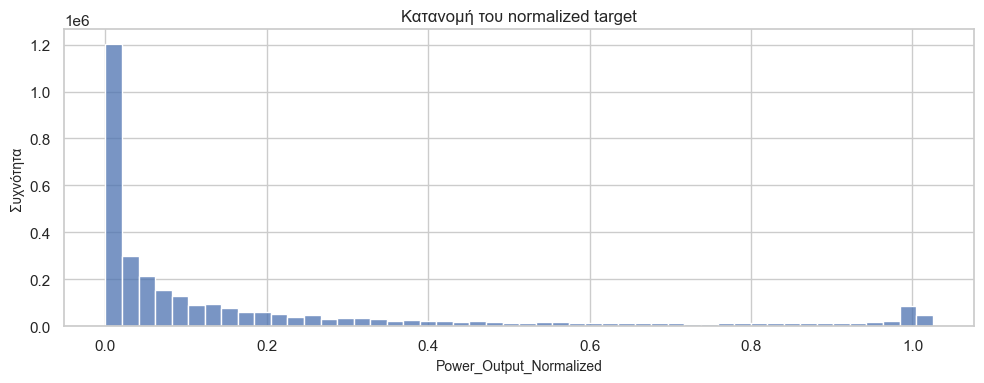

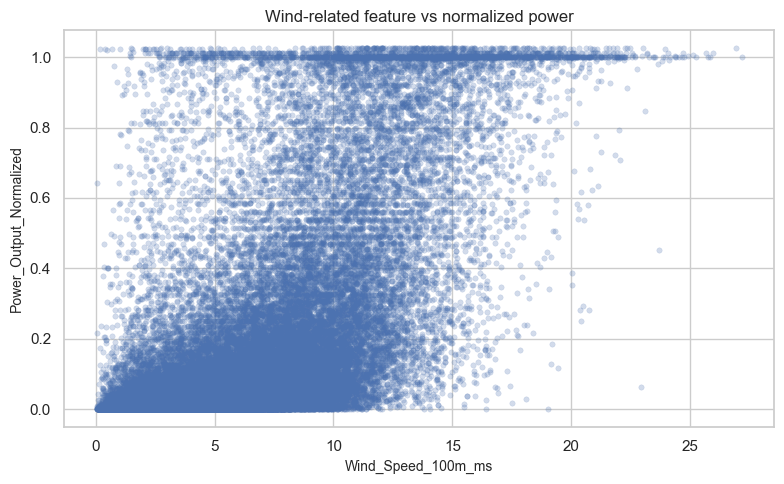

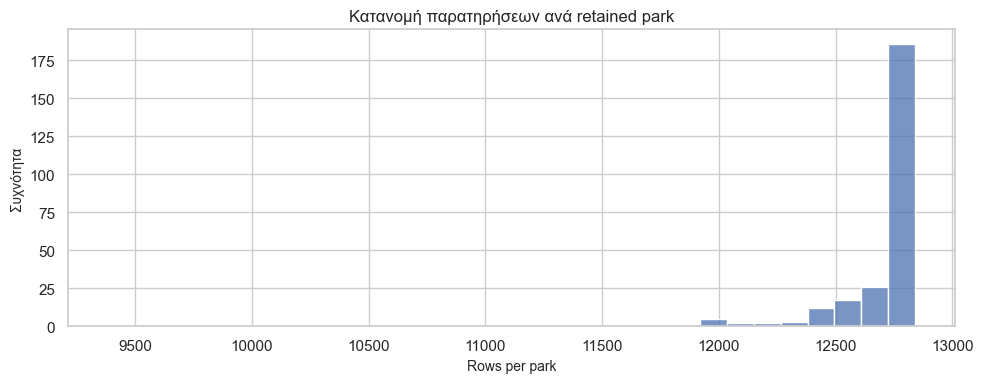

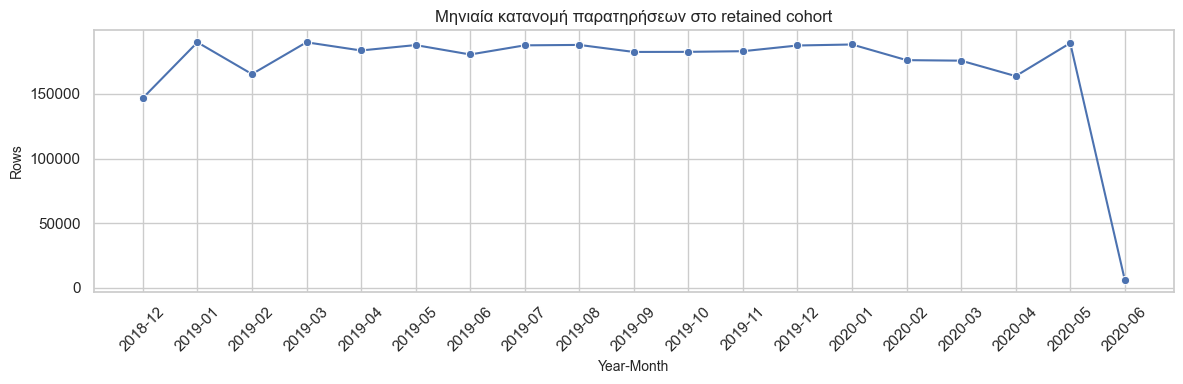

In [7]:
# --------------------------------------------------------------
# NB03 | Visual EDA πάνω στο strict downstream cohort
# --------------------------------------------------------------

# --------------------------------------------------------------
# 1. Κατανομή target
# --------------------------------------------------------------
plt.figure(figsize=(10, 4))
sns.histplot(master_df[TARGET_COL].dropna(), bins=50)
plt.title("Κατανομή του normalized target")
plt.xlabel(TARGET_COL)
plt.ylabel("Συχνότητα")
plt.tight_layout()
plt.show()

# --------------------------------------------------------------
# 2. Wind vs target scatter σε sample για readability
# --------------------------------------------------------------
scatter_df = master_df[[WIND_COL, TARGET_COL]].dropna().copy()

if len(scatter_df) > 50000:
    scatter_df = scatter_df.sample(n=50000, random_state=RANDOM_SEED)

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=scatter_df,
    x=WIND_COL,
    y=TARGET_COL,
    s=15,
    alpha=0.25,
    edgecolor=None,
)
plt.title("Wind-related feature vs normalized power")
plt.xlabel(WIND_COL)
plt.ylabel(TARGET_COL)
plt.tight_layout()
plt.show()

# --------------------------------------------------------------
# 3. Rows ανά park
# --------------------------------------------------------------
park_row_counts_df = (
    park_summary_df[["park_id", "rows"]]
    .sort_values("rows", ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 4))
sns.histplot(park_row_counts_df["rows"], bins=30)
plt.title("Κατανομή παρατηρήσεων ανά retained park")
plt.xlabel("Rows per park")
plt.ylabel("Συχνότητα")
plt.tight_layout()
plt.show()

# --------------------------------------------------------------
# 4. Monthly observation counts
# --------------------------------------------------------------
monthly_counts_df = (
    master_df
    .assign(year_month=master_df[TIMESTAMP_COLUMN].dt.to_period("M").astype(str))
    .groupby("year_month", as_index=False)
    .size()
    .rename(columns={"size": "rows"})
)

plt.figure(figsize=(12, 4))
sns.lineplot(data=monthly_counts_df, x="year_month", y="rows", marker="o")
plt.title("Μηνιαία κατανομή παρατηρήσεων στο retained cohort")
plt.xlabel("Year-Month")
plt.ylabel("Rows")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
# --------------------------------------------------------------
# NB03 | Canonical exports
# --------------------------------------------------------------

# Το master dataset αποτελεί canonical validated-only / NB04-eligible assembly output.
master_df.to_csv(MASTER_DATASET, index=False)
schema_summary_df.to_csv(MASTER_SCHEMA_SUMMARY, index=False)
park_summary_df.to_csv(MASTER_PARK_SUMMARY, index=False)
anomaly_profile_df.to_csv(MASTER_ANOMALY_PROFILE, index=False)
park_load_summary_df.to_csv(MASTER_PARK_LOAD_SUMMARY, index=False)

print("NB03 exports saved successfully:")
print(f" - MASTER_DATASET           : {MASTER_DATASET}")
print(f" - MASTER_SCHEMA_SUMMARY    : {MASTER_SCHEMA_SUMMARY}")
print(f" - MASTER_PARK_SUMMARY      : {MASTER_PARK_SUMMARY}")
print(f" - MASTER_ANOMALY_PROFILE   : {MASTER_ANOMALY_PROFILE}")
print(f" - MASTER_PARK_LOAD_SUMMARY : {MASTER_PARK_LOAD_SUMMARY}")

NB03 exports saved successfully:
 - MASTER_DATASET           : C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\master_dataset.csv
 - MASTER_SCHEMA_SUMMARY    : C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\master_schema_summary.csv
 - MASTER_PARK_SUMMARY      : C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\master_park_summary.csv
 - MASTER_ANOMALY_PROFILE   : C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\master_anomaly_profile.csv
 - MASTER_PARK_LOAD_SUMMARY : C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\master_park_load_summary.csv


## Συμπέρασμα

Το `NB03` ολοκλήρωσε το **validated-only και coverage-aware master assembly** του DaKS pipeline.

### Τι επιβεβαιώθηκε

- το notebook **δεν** ξαναέκανε raw validation
- το canonical timestamp backbone χρησιμοποιήθηκε όπως παραδόθηκε από το upstream contract
- το actual `master_df` χτίστηκε μόνο από parks με `nb04_eligible == True`
- έγιναν fail-fast integrity checks για:
  - missing timestamps
  - duplicate `(park_id, timestamp)`
  - non-monotonic temporal backbone
  - missing critical metadata

### Τι εξάγεται

- `master_dataset.csv`
- `master_schema_summary.csv`
- `master_park_summary.csv`
- `master_anomaly_profile.csv`
- `master_park_load_summary.csv`

### Ρόλος του notebook στο pipeline

Το `NB03` λειτουργεί πλέον ως:

> validated-only, coverage-aware master EDA stage

και παραδίδει ένα καθαρό downstream dataset για το `NB04`, χωρίς να συγχέει:

- raw-valid parks
- και strict benchmark-ready cohort parks